# 🌡️ FLIR Thermal — Object Detection with YOLOv8s

| | |
|---|---|
| **Dataset** | [FLIR Thermal Reduced](https://www.kaggle.com/datasets/albertofv/flir-thermal-images-dataset-reduced) |
| **Model** | YOLOv8s (pretrained COCO weights) |
| **Classes** | `person` `car` `bike` `light` `sign` |
| **Pipeline** | Download → Annotate → Preprocess → Train → Evaluate |

> Make sure **Runtime → Change runtime type → GPU (T4)** is selected before running.

## 1 · Packages & Global Config

In [1]:
!pip install ultralytics kaggle --quiet

import os, json, zipfile, random, subprocess, warnings
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from tqdm.auto import tqdm
import torch
from ultralytics import YOLO
from sklearn.metrics import (
    classification_report, matthews_corrcoef, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

# ---- Paths ----------------------------------------------------------------
ROOT        = Path('/content/flir_work')
RAW_DIR     = ROOT / 'raw'
DATASET_DIR = ROOT / 'dataset'
RUNS_DIR    = ROOT / 'runs'
YAML_PATH   = ROOT / 'flir_thermal.yaml'
for d in [ROOT, RAW_DIR, DATASET_DIR, RUNS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---- Class config ---------------------------------------------------------
YOLO_NAMES = {0: 'person', 1: 'car', 2: 'bike', 3: 'light', 4: 'sign'}
N_CLS      = 5
CLS_COLORS = {0:(255,80,80), 1:(80,80,255), 2:(80,200,80),
              3:(255,200,0), 4:(200,60,255)}
KEYWORD_MAP = {
    'person':0, 'car':1, 'bicycle':2, 'bike':2,
    'traffic light':3, 'light':3,
    'street sign':4, 'stop sign':4, 'sign':4,
}

# ---- GPU check ------------------------------------------------------------
print(f'PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    !nvidia-smi --query-gpu=name,memory.total --format=csv,noheader


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch 2.11.0+cu128  |  CUDA: True
GPU: Tesla T4
Tesla T4, 15360 MiB


## 2 · Dataset Download

Upload `kaggle.json` when prompted (*kaggle.com → Account → API → Create New Token*).

In [ ]:
from google.colab import files as colab_files

# ---- Kaggle auth ----------------------------------------------------------
kdir = Path('/root/.config/kaggle')
kdir.mkdir(parents=True, exist_ok=True)
kjson = kdir / 'kaggle.json'
if not kjson.exists():
    print('Upload kaggle.json:')
    up = colab_files.upload()
    for name, data in up.items():
        kjson.write_bytes(data)
    kjson.chmod(0o600)
    print('Saved.')

# ---- Download + unzip -----------------------------------------------------
zip_file = ROOT / 'flir-thermal-images-dataset-reduced.zip'
if not (RAW_DIR / 'train').exists():
    if not zip_file.exists():
        print('Downloading...')
        subprocess.run(
            ['kaggle', 'datasets', 'download',
             '-d', 'albertofv/flir-thermal-images-dataset-reduced',
             '--path', str(ROOT)],
            check=True
        )
    print('Unzipping...')
    with zipfile.ZipFile(zip_file, 'r') as z:
        z.extractall(RAW_DIR)
    print('Done.')
else:
    print('Already extracted.')

# ---- Locate split dirs ----------------------------------------------------
def find_split(base, name):
    direct = base / name
    if direct.is_dir() and (direct / 'thermal_8_bit').is_dir():
        return direct
    for p in base.rglob(name):
        if p.is_dir() and (p / 'thermal_8_bit').is_dir():
            return p
    raise FileNotFoundError(f'{name} not found under {base}')

TRAIN_RAW = find_split(RAW_DIR, 'train')
VAL_RAW   = find_split(RAW_DIR, 'val')

n_tr = len(list((TRAIN_RAW/'thermal_8_bit').glob('*.jpeg')))
n_va = len(list((VAL_RAW  /'thermal_8_bit').glob('*.jpeg')))
print(f'Train: {n_tr} images  |  Val: {n_va} images')


## 3 · Annotation Conversion (COCO → YOLO)

We keep only `person`, `car`, `bike`, `light`, `sign` and convert `[x, y, w, h]` absolute pixels to `[xc, yc, w, h]` normalised [0,1].

In [3]:
def build_cat_map(categories):
    mapping = {}
    for cat in categories:
        nl = cat['name'].lower()
        for kw, yid in KEYWORD_MAP.items():
            if kw in nl and cat['id'] not in mapping:
                mapping[cat['id']] = yid
                break
    return mapping


def coco_to_yolo(split_raw, split_name):
    img_dir    = split_raw / 'thermal_8_bit'
    ann_file   = split_raw / 'thermal_annotations.json'
    dst_labels = DATASET_DIR / 'labels' / split_name
    dst_labels.mkdir(parents=True, exist_ok=True)

    with open(ann_file) as f:
        coco = json.load(f)

    cat_map = build_cat_map(coco['categories'])

    # image_id -> filename
    if 'images' in coco:
        id2file = {img['id']: Path(img['file_name']).name
                   for img in coco['images']}
    else:
        # Fallback: sorted files, 0-indexed
        files   = sorted(img_dir.glob('*.jpeg'))
        id2file = {i: f.name for i, f in enumerate(files)}

    ann_by_img = defaultdict(list)
    for ann in coco['annotations']:
        if ann.get('iscrowd', 0) == 0 and ann['category_id'] in cat_map:
            ann_by_img[ann['image_id']].append(ann)

    converted = 0
    for img_id, anns in ann_by_img.items():
        fname = id2file.get(img_id)
        if not fname:
            continue
        src = img_dir / fname
        if not src.exists():
            continue
        tmp = cv2.imread(str(src))
        if tmp is None:
            continue
        h_px, w_px = tmp.shape[:2]

        lines = []
        for ann in anns:
            bx, by, bw, bh = ann['bbox']
            xc = float(np.clip((bx + bw/2) / w_px, 0, 1))
            yc = float(np.clip((by + bh/2) / h_px, 0, 1))
            wn = float(np.clip(bw / w_px, 0, 1))
            hn = float(np.clip(bh / h_px, 0, 1))
            if wn > 1e-4 and hn > 1e-4:
                yid = cat_map[ann['category_id']]
                lines.append(f'{yid} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}')

        if lines:
            out = dst_labels / (src.stem + '.txt')
            out.write_text('\n'.join(lines))
            converted += 1

    print(f'  [{split_name}] {converted} label files written')
    return coco, cat_map


print('Converting...')
TRAIN_COCO, TRAIN_MAP = coco_to_yolo(TRAIN_RAW, 'train')
VAL_COCO,   VAL_MAP   = coco_to_yolo(VAL_RAW,   'val')

ALL_CATS = {c['id']: c['name'] for c in TRAIN_COCO['categories']}
print('\nCOCO -> YOLO mapping:')
for cid, yid in sorted(TRAIN_MAP.items()):
    print(f'  COCO {cid:>3}  {ALL_CATS[cid]:<22} -> YOLO {yid} ({YOLO_NAMES[yid]})')


Converting...
  [train] 7859 label files written
  [val] 1360 label files written

COCO -> YOLO mapping:
  COCO   1  person                 -> YOLO 0 (person)
  COCO   2  bicycle                -> YOLO 2 (bike)
  COCO   3  car                    -> YOLO 1 (car)
  COCO  10  traffic light          -> YOLO 3 (light)
  COCO  12  stop sign              -> YOLO 4 (sign)
  COCO  52  carrot                 -> YOLO 1 (car)
  COCO  71  bike                   -> YOLO 2 (bike)
  COCO  75  light                  -> YOLO 3 (light)
  COCO  76  sign                   -> YOLO 4 (sign)


In [4]:
yaml_text = (
    'path: ' + str(DATASET_DIR) + '\n'
    'train: images/train\n'
    'val:   images/val\n\n'
    'nc: 5\n'
    'names:\n'
    '  0: person\n'
    '  1: car\n'
    '  2: bike\n'
    '  3: light\n'
    '  4: sign\n'
)
YAML_PATH.write_text(yaml_text)
print('YAML saved:', YAML_PATH)
print()
print(yaml_text)


YAML saved: /content/flir_work/flir_thermal.yaml

path: /content/flir_work/dataset
train: images/train
val:   images/val

nc: 5
names:
  0: person
  1: car
  2: bike
  3: light
  4: sign



## 4 · Exploratory Data Analysis

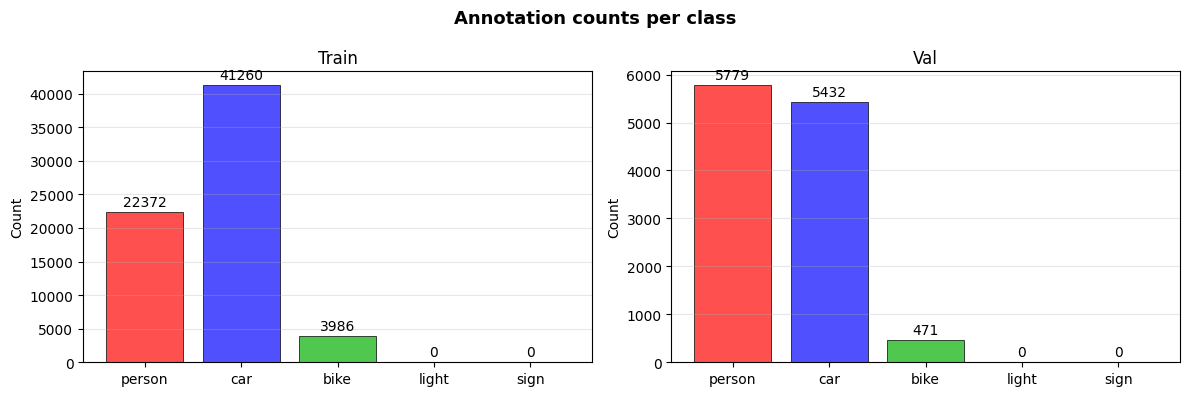

In [5]:
# ---- Annotation counts per class -----------------------------------------
def count_cls(coco, cat_map):
    c = Counter()
    for ann in coco['annotations']:
        if ann['category_id'] in cat_map:
            c[cat_map[ann['category_id']]] += 1
    return c

tr_cnt = count_cls(TRAIN_COCO, TRAIN_MAP)
va_cnt = count_cls(VAL_COCO,   VAL_MAP)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Annotation counts per class', fontsize=13, fontweight='bold')
for ax, cnt, title in [(axes[0], tr_cnt, 'Train'), (axes[1], va_cnt, 'Val')]:
    names_ordered = [YOLO_NAMES[i] for i in range(N_CLS)]
    vals   = [cnt.get(i, 0) for i in range(N_CLS)]
    colors = [np.array(CLS_COLORS[i])/255 for i in range(N_CLS)]
    bars   = ax.bar(names_ordered, vals, color=colors, edgecolor='black', lw=0.5)
    ax.bar_label(bars, fmt='%d', fontsize=10, padding=2)
    ax.set_title(title); ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


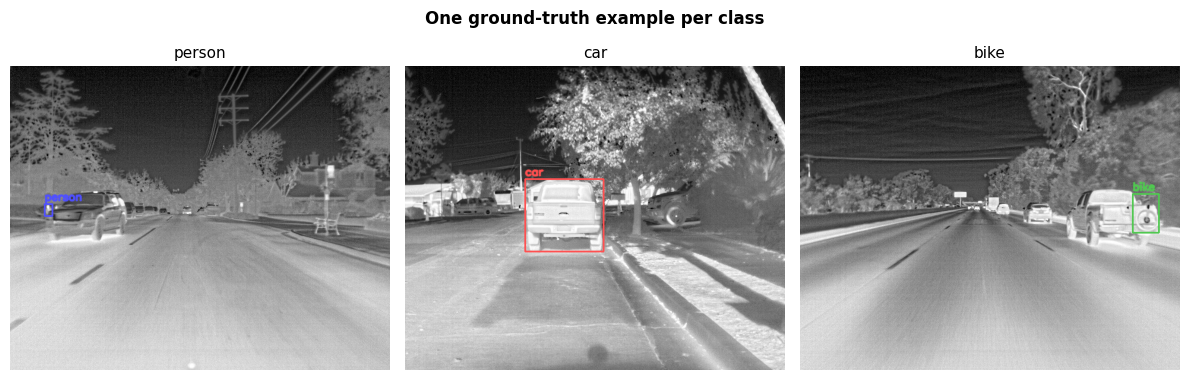

In [6]:
# ---- One image example per class with GT bbox ----------------------------
def find_examples(coco, cat_map, img_dir):
    examples = {}
    if 'images' in coco:
        id2file = {img['id']: Path(img['file_name']).name
                   for img in coco['images']}
    else:
        files   = sorted(img_dir.glob('*.jpeg'))
        id2file = {i: f.name for i, f in enumerate(files)}

    ann_by_img = defaultdict(list)
    for ann in coco['annotations']:
        if ann['category_id'] in cat_map:
            ann_by_img[ann['image_id']].append(ann)

    for img_id, anns in ann_by_img.items():
        if len(examples) == N_CLS:
            break
        fname = id2file.get(img_id)
        if not fname:
            continue
        img = cv2.imread(str(img_dir / fname))
        if img is None:
            continue
        for ann in anns:
            yid = cat_map[ann['category_id']]
            if yid not in examples:
                examples[yid] = (img.copy(), ann['bbox'], yid)
    return examples

examples = find_examples(TRAIN_COCO, TRAIN_MAP, TRAIN_RAW/'thermal_8_bit')

n_ex = len(examples)
fig, axes = plt.subplots(1, max(n_ex,1), figsize=(4*max(n_ex,1), 4))
if n_ex == 1: axes = [axes]
fig.suptitle('One ground-truth example per class', fontsize=12, fontweight='bold')

for ax, (yid, (img_bgr, bbox, _)) in zip(axes, sorted(examples.items())):
    vis = img_bgr.copy()
    bx, by, bw, bh = [int(v) for v in bbox]
    col = CLS_COLORS[yid]
    cv2.rectangle(vis, (bx,by), (bx+bw,by+bh), col, 2)
    cv2.putText(vis, YOLO_NAMES[yid], (bx, max(by-6,12)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 2, cv2.LINE_AA)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(YOLO_NAMES[yid], fontsize=11)
    ax.axis('off')

plt.tight_layout(); plt.show()


## 5 · Preprocessing Pipeline

Steps applied to every thermal image:

| # | Step | Purpose |
|---|---|---|
| 1 | **Min-Max normalisation** | Equalise brightness across frames |
| 2 | **Bilateral filter** | Remove sensor noise, preserve edges |
| 3 | **CLAHE** | Boost local contrast |
| 4 | **Unsharp mask** | Sharpen object boundaries |
| 5 | **Gray → BGR** | 3-channel input for YOLOv8 |

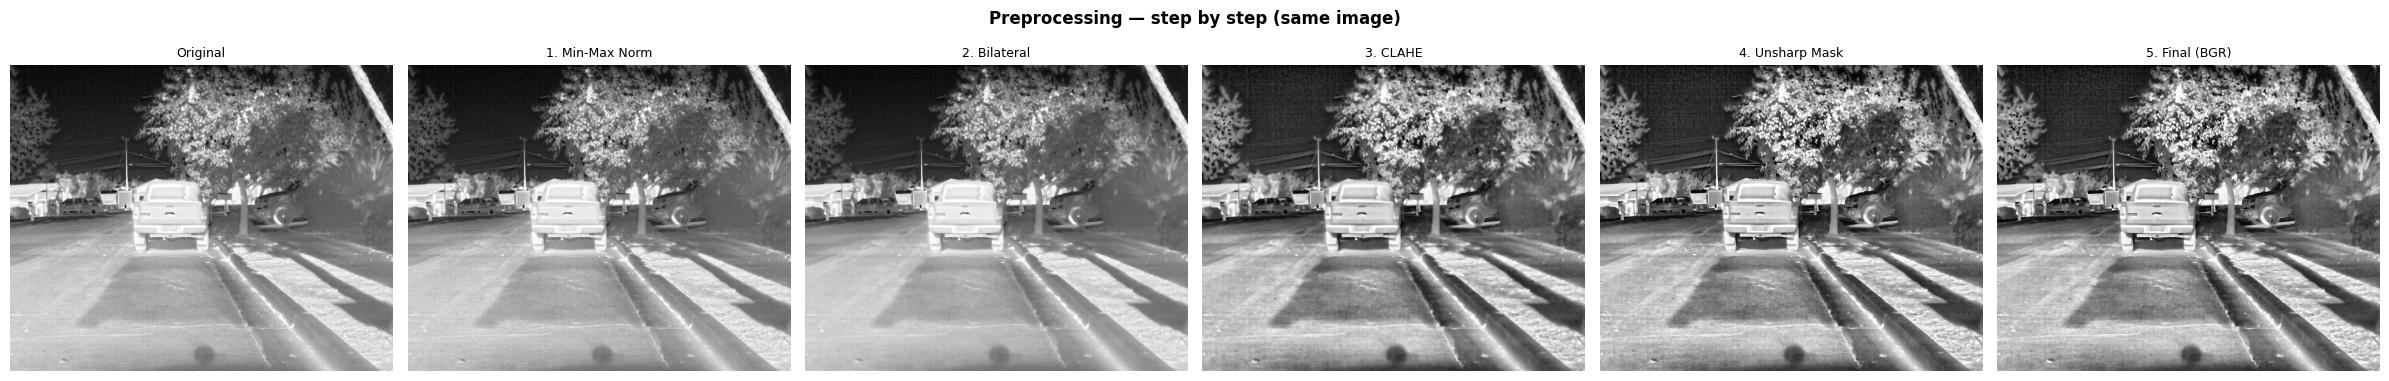

In [7]:
# ---- Preprocessing functions -----------------------------------------------
def min_max_norm(img):
    mn, mx = img.min(), img.max()
    return ((img - mn) / (mx - mn + 1e-6) * 255).astype(np.uint8)

def bilateral(img):
    return cv2.bilateralFilter(img, d=5, sigmaColor=15, sigmaSpace=15)

def clahe(img, clip=2.0, tile=8):
    op = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
    return op.apply(img)

def unsharp(img, strength=0.6):
    blur = cv2.GaussianBlur(img, (5,5), 0)
    return np.clip(
        cv2.addWeighted(img, 1+strength, blur, -strength, 0),
        0, 255
    ).astype(np.uint8)

def full_pipeline(gray):
    s1 = min_max_norm(gray)
    s2 = bilateral(s1)
    s3 = clahe(s2)
    s4 = unsharp(s3)
    s5 = cv2.cvtColor(s4, cv2.COLOR_GRAY2BGR)
    return s1, s2, s3, s4, s5


# ---- Step-by-step visualisation on ONE sample image ----------------------
sample_path = sorted((TRAIN_RAW/'thermal_8_bit').glob('*.jpeg'))[0]
raw_gray    = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)
s1, s2, s3, s4, s5 = full_pipeline(raw_gray)

stages = [
    ('Original',         raw_gray, 'gray'),
    ('1. Min-Max Norm',  s1,       'gray'),
    ('2. Bilateral',     s2,       'gray'),
    ('3. CLAHE',         s3,       'gray'),
    ('4. Unsharp Mask',  s4,       'gray'),
    ('5. Final (BGR)',   cv2.cvtColor(s5, cv2.COLOR_BGR2RGB), None),
]

fig, axes = plt.subplots(1, 6, figsize=(24, 4))
fig.suptitle('Preprocessing — step by step (same image)',
             fontsize=12, fontweight='bold')
for ax, (title, img, cmap) in zip(axes, stages):
    kw = {'cmap': cmap} if cmap else {}
    ax.imshow(img, **kw)
    ax.set_title(title, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()


In [8]:
# ---- Apply to entire dataset -----------------------------------------------
def apply_to_split(raw_img_dir, dst_img_dir):
    dst_img_dir.mkdir(parents=True, exist_ok=True)
    jpegs = sorted(raw_img_dir.glob('*.jpeg'))
    for src in tqdm(jpegs, desc=str(dst_img_dir.parent.name+'/'+dst_img_dir.name)):
        gray = cv2.imread(str(src), cv2.IMREAD_GRAYSCALE)
        if gray is None: continue
        *_, bgr = full_pipeline(gray)
        cv2.imwrite(
            str(dst_img_dir / (src.stem + '.jpg')),
            bgr, [cv2.IMWRITE_JPEG_QUALITY, 95]
        )

apply_to_split(TRAIN_RAW/'thermal_8_bit', DATASET_DIR/'images'/'train')
apply_to_split(VAL_RAW  /'thermal_8_bit', DATASET_DIR/'images'/'val')

# Verify image-label pairing
for split in ['train', 'val']:
    imgs = {p.stem for p in (DATASET_DIR/'images'/split).glob('*.jpg')}
    lbls = {p.stem for p in (DATASET_DIR/'labels'/split).glob('*.txt')}
    matched = imgs & lbls
    print(f'[{split}]  images={len(imgs)}  labels={len(lbls)}  paired={len(matched)}')


images/train:   0%|          | 0/8862 [00:00<?, ?it/s]

images/val:   0%|          | 0/1366 [00:00<?, ?it/s]

[train]  images=8862  labels=7859  paired=7859
[val]  images=1366  labels=1360  paired=1360


## 6 · Training

**Strategy:**
1. **Phase 1** — Freeze backbone (first 10 layers), train detection head only, 5 epochs, lr=1e-3
2. **Phase 2** — Unfreeze all layers, full fine-tune, 5 epochs, lr=1e-4

All data augmentation is disabled to keep the thermal preprocessing intact.

### Phase 1 — Frozen Backbone

In [9]:
# No-augmentation config
NO_AUG = dict(
    degrees=0.0, translate=0.0, scale=0.0, shear=0.0,
    perspective=0.0, flipud=0.0, fliplr=0.0,
    mosaic=0.0, mixup=0.0, copy_paste=0.0,
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
)

model_p1 = YOLO('yolov8s.pt')   # downloads pretrained COCO weights

model_p1.train(
    data=str(YAML_PATH),
    epochs=5,
    imgsz=640,
    batch=-1,         # auto-batch for T4
    freeze=10,        # freeze backbone layers 0-9
    lr0=1e-3,
    lrf=0.1,
    workers=2,
    project=str(RUNS_DIR),
    name='phase1',
    exist_ok=True,
    **NO_AUG
)

PHASE1_BEST = RUNS_DIR / 'phase1' / 'weights' / 'best.pt'
print('Phase 1 done. Best weights ->', PHASE1_BEST)


Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/flir_work/flir_thermal.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=phase1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

### Phase 2 — Full Fine-tune

In [10]:
model_p2 = YOLO(str(PHASE1_BEST))

model_p2.train(
    data=str(YAML_PATH),
    epochs=5,
    imgsz=640,
    batch=-1,
    lr0=1e-4,
    lrf=0.1,
    workers=2,
    project=str(RUNS_DIR),
    name='phase2',
    exist_ok=True,
    **NO_AUG
)

FINAL_WEIGHTS = RUNS_DIR / 'phase2' / 'weights' / 'best.pt'
print('Phase 2 done. Final model  ->', FINAL_WEIGHTS)


Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/flir_work/flir_thermal.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/flir_work/runs/phase1/weights/best.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=phase2, nbs=64, nms=False, opset=None, optimize=False, optimiz

## 7 · Training Curves

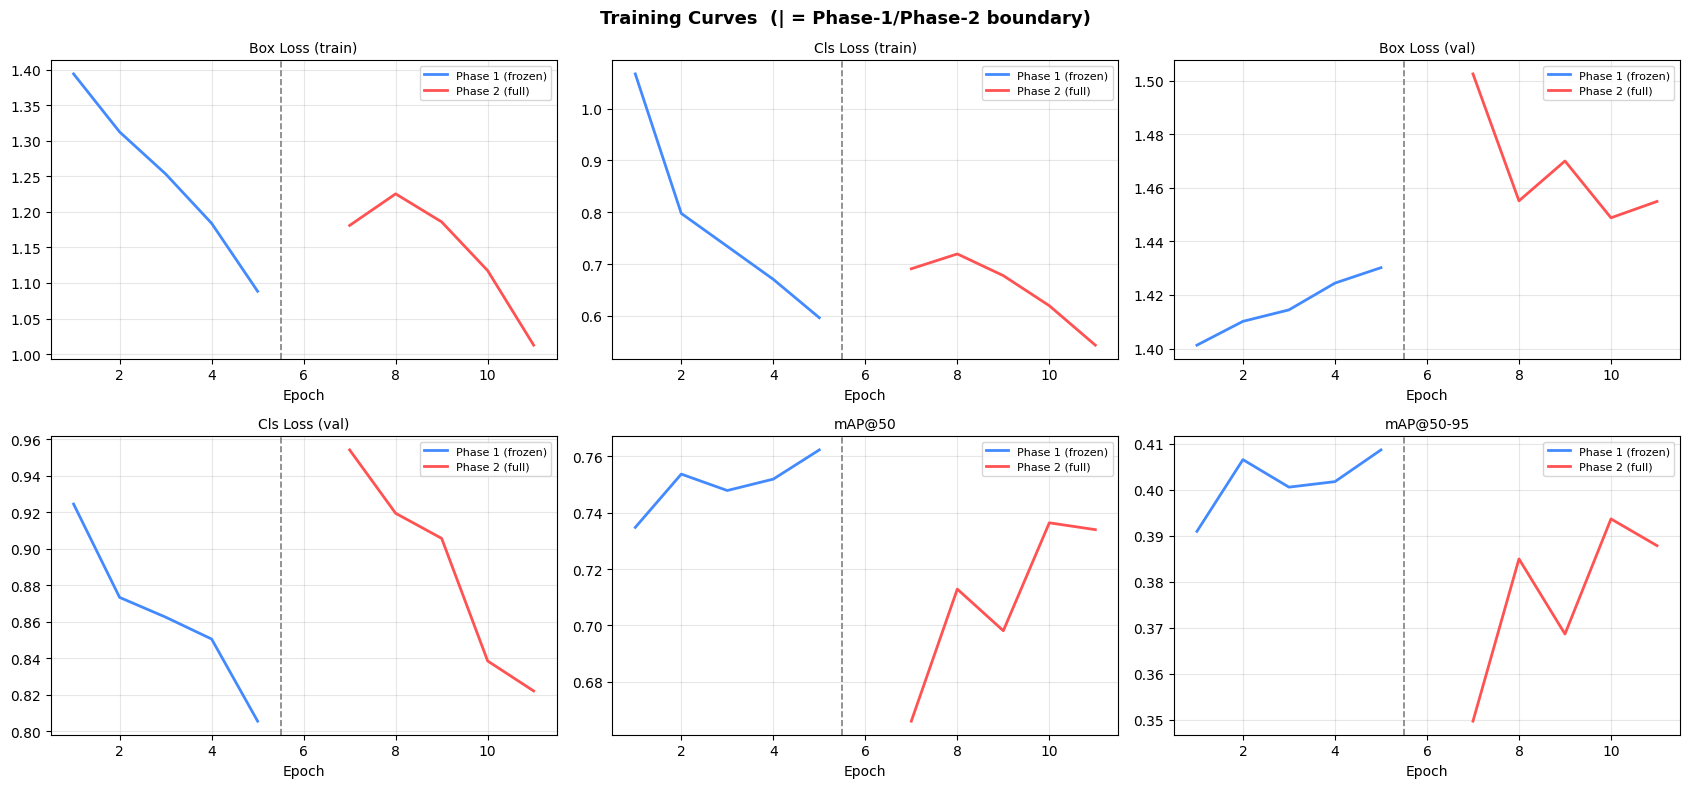

In [11]:
def load_csv(run_dir):
    df = pd.read_csv(Path(run_dir) / 'results.csv')
    df.columns = df.columns.str.strip()
    return df

df1 = load_csv(RUNS_DIR / 'phase1')
df2 = load_csv(RUNS_DIR / 'phase2')

# Offset phase-2 epochs so they continue from phase-1
p1_end = int(df1['epoch'].max())
df2c   = df2.copy()
df2c['epoch'] = df2['epoch'] + p1_end + 1
df_all = pd.concat([df1, df2c], ignore_index=True)

PLOTS = [
    ('train/box_loss',        'Box Loss (train)'),
    ('train/cls_loss',        'Cls Loss (train)'),
    ('val/box_loss',          'Box Loss (val)'),
    ('val/cls_loss',          'Cls Loss (val)'),
    ('metrics/mAP50(B)',      'mAP@50'),
    ('metrics/mAP50-95(B)',   'mAP@50-95'),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
fig.suptitle('Training Curves  (| = Phase-1/Phase-2 boundary)',
             fontsize=13, fontweight='bold')

for ax, (col, title) in zip(axes.flat, PLOTS):
    if col not in df_all.columns:
        ax.set_visible(False); continue
    # Phase 1
    mask1 = df_all['epoch'] <= p1_end
    ax.plot(df_all.loc[mask1,'epoch'], df_all.loc[mask1,col],
            color='#448AFF', lw=2, label='Phase 1 (frozen)')
    # Phase 2
    mask2 = df_all['epoch'] > p1_end
    ax.plot(df_all.loc[mask2,'epoch'], df_all.loc[mask2,col],
            color='#FF5252', lw=2, label='Phase 2 (full)')
    ax.axvline(p1_end + 0.5, color='gray', ls='--', lw=1.2)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 8 · Evaluation Metrics

We compute:
- **mAP@50 / mAP@50-95** — standard YOLO object-detection metrics
- **Precision / Recall / F1** — per class and macro
- **MCC** — Matthews Correlation Coefficient (robust to class imbalance)
- **Classification report + Confusion matrix** — over matched GT boxes (IoU ≥ 0.5)

In [12]:
# ---- Load final model & run official val ----------------------------------
FINAL = YOLO(str(FINAL_WEIGHTS))

print('Running official YOLO validation...')
vr = FINAL.val(data=str(YAML_PATH), verbose=False)

print(f'\n  mAP@50      : {vr.box.map50:.4f}')
print(f'  mAP@50-95   : {vr.box.map:.4f}')
print(f'  Precision   : {vr.box.mp:.4f}')
print(f'  Recall      : {vr.box.mr:.4f}')

print('\nPer-class mAP@50:')
try:
    for i, ap50 in enumerate(vr.box.ap50):
        idx = vr.box.ap_class_index[i] if hasattr(vr.box,'ap_class_index') else i
        f1_val = 2*vr.box.p[i]*vr.box.r[i] / (vr.box.p[i]+vr.box.r[i]+1e-6)
        print(f'  {YOLO_NAMES.get(idx,idx):<8} '
              f'AP50={ap50:.3f}  P={vr.box.p[i]:.3f}  '
              f'R={vr.box.r[i]:.3f}  F1={f1_val:.3f}')
except Exception as e:
    print(f'  (per-class details unavailable: {e})')


Running official YOLO validation...
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2191.1±839.3 MB/s, size: 145.5 KB)
val: Scanning /content/flir_work/dataset/labels/val.cache... 1360 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1366/1366 358.1Mit/s 0.0s
val: /content/flir_work/dataset/images/val/FLIR_09042.jpg: 1 duplicate labels removed
val: /content/flir_work/dataset/images/val/FLIR_09055.jpg: 1 duplicate labels removed
val: /content/flir_work/dataset/images/val/FLIR_09653.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 86/86 4.5it/s 19.2s
                   all       1366      11679      0.756      0.657      0.737      0.394
Speed: 1.2ms preprocess, 7.6ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved

In [13]:
# ---- Custom inference-based evaluation (for MCC + sklearn report) ---------

VAL_IMGS_DIR = DATASET_DIR / 'images' / 'val'
VAL_LBL_DIR  = DATASET_DIR / 'labels' / 'val'

def xywhn_to_xyxy(b):
    xc,yc,w,h = b[1],b[2],b[3],b[4]
    return [xc-w/2, yc-h/2, xc+w/2, yc+h/2]

def iou_boxes(a, b):
    x1,y1 = max(a[0],b[0]), max(a[1],b[1])
    x2,y2 = min(a[2],b[2]), min(a[3],b[3])
    inter  = max(0,x2-x1)*max(0,y2-y1)
    union  = (a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter
    return inter/(union+1e-6)

y_true, y_pred = [], []

for img_path in tqdm(sorted(VAL_IMGS_DIR.glob('*.jpg')), desc='Eval'):
    lbl_path = VAL_LBL_DIR / (img_path.stem + '.txt')

    gt = []
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            p = line.split()
            if len(p) == 5:
                gt.append([int(p[0])] + [float(x) for x in p[1:]])

    res   = FINAL.predict(str(img_path), conf=0.25, verbose=False)[0]
    preds = []
    if res.boxes is not None and len(res.boxes):
        for box in res.boxes:
            preds.append(
                [int(box.cls)] + box.xywhn[0].cpu().numpy().tolist()
            )

    gt_xy   = [xywhn_to_xyxy(g) for g in gt]
    pred_xy = [xywhn_to_xyxy(p) for p in preds]

    matched_gt = set()
    for pi, pred in enumerate(preds):
        best_v, best_gi = 0.0, -1
        for gi, g in enumerate(gt):
            if gi in matched_gt or g[0] != pred[0]: continue
            v = iou_boxes(pred_xy[pi], gt_xy[gi])
            if v > best_v: best_v, best_gi = v, gi
        if best_v >= 0.5 and best_gi >= 0:
            matched_gt.add(best_gi)

    # For each GT box: matched=TP, unmatched=FN
    for gi, g in enumerate(gt):
        y_true.append(g[0])
        y_pred.append(g[0] if gi in matched_gt else N_CLS)  # N_CLS = 'missed'

y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(f'Evaluated {len(y_true)} GT boxes')


Eval:   0%|          | 0/1366 [00:00<?, ?it/s]

Evaluated 11682 GT boxes


In [14]:
# ---- Classification report ------------------------------------------------
all_labels = list(range(N_CLS + 1))
tgt_names  = [YOLO_NAMES[i] for i in range(N_CLS)] + ['missed']

print('Classification Report (per GT box, IoU>=0.5)\n')
print(classification_report(
    y_true, y_pred,
    labels=all_labels,
    target_names=tgt_names,
    zero_division=0
))

# ---- F1 per class ---------------------------------------------------------
f1_per = f1_score(y_true, y_pred,
                   labels=list(range(N_CLS)), average=None, zero_division=0)
f1_mac = f1_score(y_true, y_pred,
                   labels=list(range(N_CLS)), average='macro', zero_division=0)
print('F1 per class:')
for i, v in enumerate(f1_per):
    print(f'  {YOLO_NAMES[i]:<8}: {v:.4f}')
print(f'F1 macro  : {f1_mac:.4f}')

# ---- MCC ------------------------------------------------------------------
mcc = matthews_corrcoef(y_true, y_pred)
print(f'MCC       : {mcc:.4f}')


Classification Report (per GT box, IoU>=0.5)

              precision    recall  f1-score   support

      person       1.00      0.80      0.89      5779
         car       1.00      0.87      0.93      5432
        bike       1.00      0.59      0.74       471
       light       0.00      0.00      0.00         0
        sign       0.00      0.00      0.00         0
      missed       0.00      0.00      0.00         0

    accuracy                           0.82     11682
   macro avg       0.50      0.38      0.43     11682
weighted avg       1.00      0.82      0.90     11682

F1 per class:
  person  : 0.8872
  car     : 0.9313
  bike    : 0.7440
  light   : 0.0000
  sign    : 0.0000
F1 macro  : 0.5125
MCC       : 0.7436


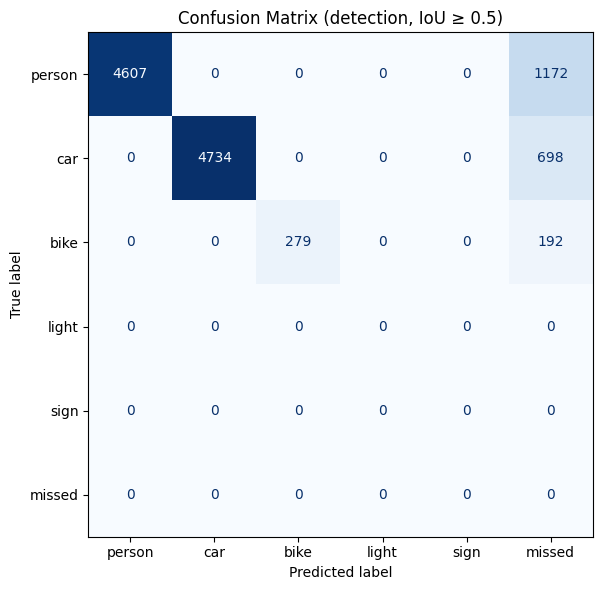

In [15]:
# ---- Confusion matrix plot ------------------------------------------------
cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLS + 1)))

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    cm,
    display_labels=[YOLO_NAMES[i] for i in range(N_CLS)] + ['missed']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (detection, IoU ≥ 0.5)', fontsize=12)
plt.tight_layout(); plt.show()


## 9 · Detection Examples (2 per class)

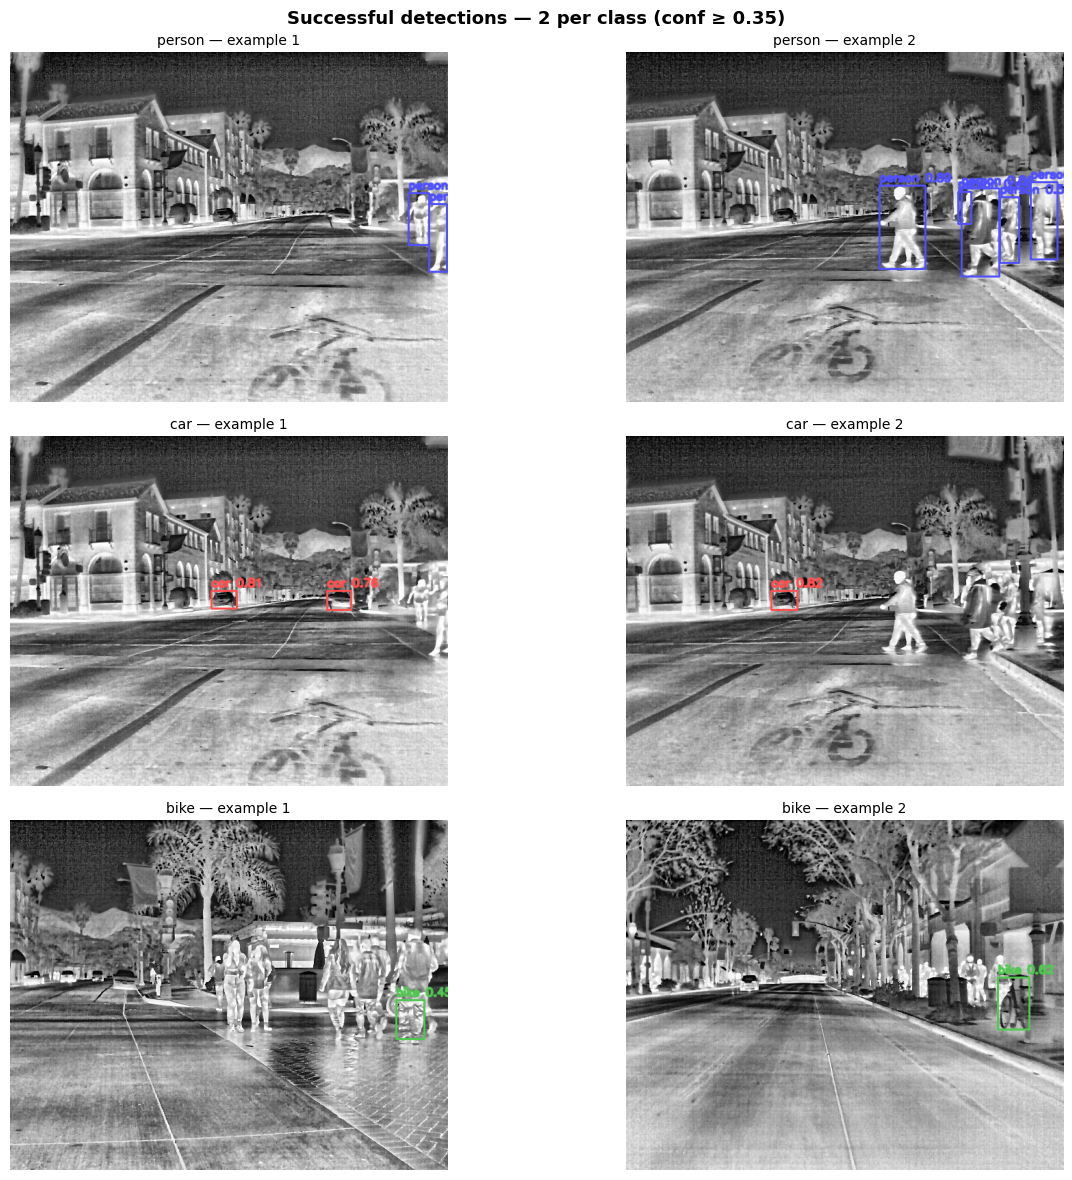

In [16]:
detected = defaultdict(list)   # class_id -> list of RGB images

for img_path in sorted(VAL_IMGS_DIR.glob('*.jpg')):
    # Stop when we have 2 examples for every class that was found
    if len(detected) == N_CLS and all(len(v)>=2 for v in detected.values()):
        break

    res = FINAL.predict(str(img_path), conf=0.35, verbose=False)[0]
    if res.boxes is None or len(res.boxes) == 0:
        continue

    img_bgr = cv2.imread(str(img_path))
    seen    = set()

    for box in res.boxes:
        cls  = int(box.cls)
        conf = float(box.conf)
        if cls not in YOLO_NAMES or conf < 0.35: continue
        if cls in seen or len(detected[cls]) >= 2: continue
        seen.add(cls)

        # Draw only boxes of this class
        drawn = img_bgr.copy()
        for b in res.boxes:
            if int(b.cls) != cls: continue
            x1,y1,x2,y2 = map(int, b.xyxy[0].cpu().numpy())
            col = CLS_COLORS[cls]
            cv2.rectangle(drawn, (x1,y1), (x2,y2), col, 2)
            lbl = f'{YOLO_NAMES[cls]} {float(b.conf):.2f}'
            cv2.putText(drawn, lbl, (x1, max(y1-6,14)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2, cv2.LINE_AA)
        detected[cls].append(cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB))

# ---- Plot -----------------------------------------------------------------
cls_found = sorted(detected.keys())
n_rows    = len(cls_found)

if n_rows == 0:
    print('No detections. Lower conf threshold and re-run.')
else:
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4*n_rows))
    if n_rows == 1: axes = np.array([axes])
    fig.suptitle('Successful detections — 2 per class (conf ≥ 0.35)',
                 fontsize=13, fontweight='bold')

    for row, cls_id in enumerate(cls_found):
        for col in range(2):
            ax = axes[row, col]
            if col < len(detected[cls_id]):
                ax.imshow(detected[cls_id][col])
                ax.set_title(
                    f'{YOLO_NAMES[cls_id]} — example {col+1}', fontsize=10)
            else:
                ax.text(0.5, 0.5, 'No example', ha='center', va='center',
                        transform=ax.transAxes, fontsize=12, color='gray')
            ax.axis('off')

    plt.tight_layout(); plt.show()
